# Проект: Өсімдік Жапырақтарының Ауруын Анықтау

## Мәселе

Ауыл шаруашылығында өсімдік аурулары жыл сайын дүние жүзі бойынша **өнімнің 20–40%** жоғалуына себеп болады. Дәстүрлі әдісте агроном далаға шығып, жапырақты көзімен тексереді, бұл баяу және қымбат. Қазіргі заманда смартфон камерасымен түсірілген сурет арқылы аурудың түрін бірнеше секундта анықтайтын жүйелер жасалуда.

**Осы Проектте-де сіз:**
- Нақты өсімдік жапырақтарының кескіндерін өңдейсіз
- Аурудың визуальды белгілерін CV әдістерімен табасыз
- Сипаттамаларды (features) шығарып, ML классификаторын оқытасыз
- Модельдің нәтижесін бағалайсыз


## Датасет: Plant Pathology (жеңілдетілген нұсқа)

**Мазмұны:** Алма ағашы жапырақтарының 4 класы:

| Класс | Сипаттама | Визуальды белгі |
|:-----:|-----------|------------------|
| `healthy` | Сау жапырақ | Біртекті жасыл түс |
| `scab` | Қотыр ауруы | Қоңыр дақтар, дөңгелек өрнек |
| `rust` | Тат ауруы | Қызғылт-сары дақтар |
| `multiple` | Бірнеше ауру | Аралас симптомдар |

> **Ескерту:** Бұл Проектте-де датасет синтетикалық түрде генерацияланады нақты өмірдегі деректерге ұқсас. Нақты Plant Village датасетін Kaggle-дан жүктеуге болады.




## Тапсырмалар жоспары

```
Қадам 1: Деректерді жүктеу және зерттеу (EDA)
  ├── 1а. Кескіндерді визуализациялау
  ├── 1б. Класс таралуын талдау          ←
  └── 1в. Пиксель статистикасы           ←

Қадам 2: Кескінді алдын ала өңдеу
  ├── 2а. Өлшемді стандарттау
  ├── 2б. Түс кеңістігіне ауыстыру       ←
  └── 2в. Шуды азайту                    ←

Қадам 3: Аурудың визуальды белгілерін табу
  ├── 3а. HSV масканы қолдану
  ├── 3б. Дақтарды сегментациялау        ←
  └── 3в. Морфологиялық тазалау          ←

Қадам 4: Сипаттама шығару (Feature Extraction)
  ├── 4а. Түс гистограммасы
  ├── 4б. Текстура сипаттамалары (LBP)   ←
  └── 4в. Форма сипаттамалары            ←

Қадам 5: ML классификация
  ├── 5а. Деректерді дайындау
  ├── 5б. Модельді оқыту                 ←
  └── 5в. Нәтижелерді бағалау            ←

Қадам 6: Талдау және қорытынды           ←
```


**Орнату:**
```bash
pip install numpy matplotlib scikit-image scikit-learn opencv-python
```

In [ ]:
# КІТАПХАНАЛАР МЕН ЖАҺАНДЫҚ ПАРАМЕТРЛЕР
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

from skimage import color, filters, morphology, measure, feature, exposure
from skimage.transform import resize
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams['figure.dpi'] = 95
plt.rcParams['axes.titlesize'] = 11

# Класс атаулары мен түстері
CLASS_NAMES  = ['healthy', 'scab', 'rust', 'multiple']
CLASS_COLORS = ['#2ecc71', '#8B4513', '#e67e22', '#9b59b6']
CLASS_KAZ    = ['Сау', 'Қотыр', 'Тат', 'Аралас']

print('Кітапханалар жүктелді!')
print(f'   NumPy      : {np.__version__}')
print(f'   OpenCV     : {cv2.__version__}')

Кітапханалар жүктелді!
   NumPy      : 2.0.2
   OpenCV     : 4.13.0


# Деректерді Жүктеу

Төмендегі ұяшықта Plant Village датасетіне негізделген **синтетикалық жапырақ кескіндері** генерацияланады. Әр класс үшін нақты ауру белгілеріне ұқсас кескіндер жасалады:

- **Сау (healthy):** Біртекті жасыл фон, табиғи текстура
- **Қотыр (scab):** Жасыл фон + қоңыр дөңгелек дақтар
- **Тат (rust):** Жасыл фон + сарғыш-қызғылт ұсақ дақтар
- **Аралас (multiple):** Бірнеше ауру симптомдарының үйлесімі

>  **Бұл ұяшықты өзгертпеңіз — оқытушы коды.**

In [ ]:
# ДАТАСЕТ ГЕНЕРАТОРЫ  — ӨЗГЕРТПЕҢІЗ

IMG_SIZE = 128   # Кескін өлшемі
N_EACH   = 60    # Әр класстан кескін саны

def make_leaf_texture(size, seed):
    """Жапырақтың табиғи текстурасын имитациялайтын фон"""
    rng  = np.random.RandomState(seed)
    base = rng.randn(size, size) * 0.04
    # Көп масштабты текстура (жапырақ тамырлары)
    for scale in [8, 16, 32]:
        small   = rng.randn(size // scale + 2, size // scale + 2)
        from skimage.transform import resize as sk_resize
        upscale = sk_resize(small, (size, size), anti_aliasing=True)
        base   += upscale * 0.06
    return base

def generate_leaf_image(cls, idx, size=IMG_SIZE):
    """Класс бойынша жапырақ кескінін генерациялайды"""
    rng     = np.random.RandomState(idx * 100 + CLASS_NAMES.index(cls))
    img     = np.zeros((size, size, 3), dtype=np.float32)
    texture = make_leaf_texture(size, idx * 10)

    # Базалық жасыл фон
    green_var  = rng.uniform(0.05, 0.15)
    img[:,:,0] = np.clip(0.15 + green_var + texture, 0, 1)  # R
    img[:,:,1] = np.clip(0.50 + green_var + texture, 0, 1)  # G
    img[:,:,2] = np.clip(0.12 + green_var + texture, 0, 1)  # B

    if cls == 'scab':
        # Қотыр: қоңыр дөңгелек дақтар
        n_spots = rng.randint(4, 10)
        for _ in range(n_spots):
            cx, cy = rng.randint(15, size-15, 2)
            r      = rng.randint(6, 18)
            yy, xx = np.ogrid[:size, :size]
            mask   = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            # Дақтың ішіне қоңыр түс
            img[:,:,0][mask] = np.clip(img[:,:,0][mask] + rng.uniform(0.25, 0.45), 0, 1)
            img[:,:,1][mask] = np.clip(img[:,:,1][mask] - rng.uniform(0.20, 0.35), 0, 1)
            img[:,:,2][mask] = np.clip(img[:,:,2][mask] - rng.uniform(0.05, 0.10), 0, 1)

    elif cls == 'rust':
        # Тат: сарғыш-қызғылт ұсақ дақтар
        n_spots = rng.randint(15, 40)
        for _ in range(n_spots):
            cx, cy = rng.randint(5, size-5, 2)
            r      = rng.randint(3, 9)
            yy, xx = np.ogrid[:size, :size]
            mask   = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[:,:,0][mask] = np.clip(img[:,:,0][mask] + rng.uniform(0.40, 0.65), 0, 1)
            img[:,:,1][mask] = np.clip(img[:,:,1][mask] + rng.uniform(0.10, 0.25), 0, 1)
            img[:,:,2][mask] = np.clip(img[:,:,2][mask] - rng.uniform(0.05, 0.12), 0, 1)

    elif cls == 'multiple':
        # Аралас: екі ауру бірге
        for _ in range(rng.randint(2, 6)):
            cx, cy = rng.randint(15, size-15, 2)
            r      = rng.randint(8, 16)
            yy, xx = np.ogrid[:size, :size]
            mask   = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[:,:,0][mask] = np.clip(img[:,:,0][mask] + 0.35, 0, 1)
            img[:,:,1][mask] = np.clip(img[:,:,1][mask] - 0.28, 0, 1)
        for _ in range(rng.randint(8, 20)):
            cx, cy = rng.randint(5, size-5, 2)
            r      = rng.randint(3, 7)
            yy, xx = np.ogrid[:size, :size]
            mask   = ((xx - cx)**2 + (yy - cy)**2) <= r**2
            img[:,:,0][mask] = np.clip(img[:,:,0][mask] + 0.45, 0, 1)
            img[:,:,1][mask] = np.clip(img[:,:,1][mask] + 0.15, 0, 1)

    return np.clip(img, 0, 1)

# Датасетті генерациялау
print('Датасет генерациялануда...')
images, labels, label_names = [], [], []

for cls in CLASS_NAMES:
    for i in range(N_EACH):
        img = generate_leaf_image(cls, i)
        images.append(img)
        labels.append(CLASS_NAMES.index(cls))
        label_names.append(cls)

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int32)

print(f'Датасет дайын!')
print(f'   Жалпы кескін саны : {len(images)}')
print(f'   Кескін өлшемі     : {images[0].shape}')
print(f'   Класс саны        : {len(CLASS_NAMES)}')
for i, (name, kaz) in enumerate(zip(CLASS_NAMES, CLASS_KAZ)):
    count = np.sum(labels == i)
    print(f'   [{i}] {name:<10} ({kaz:<8}): {count} кескін')

Датасет генерациялануда...
Датасет дайын!
   Жалпы кескін саны : 240
   Кескін өлшемі     : (128, 128, 3)
   Класс саны        : 4
   [0] healthy    (Сау     ): 60 кескін
   [1] scab       (Қотыр   ): 60 кескін
   [2] rust       (Тат     ): 60 кескін
   [3] multiple   (Аралас  ): 60 кескін


# Қадам 1: Деректерді Зерттеу (EDA)

Модельді оқытудан бұрын деректерді жақсы түсіну керек. **Exploratory Data Analysis (EDA)** кез келген ML жобасының бірінші қадамы.

### 1а. Кескіндерді Визуализациялау
>  **Оқытушы коды — өзгертпеңіз**

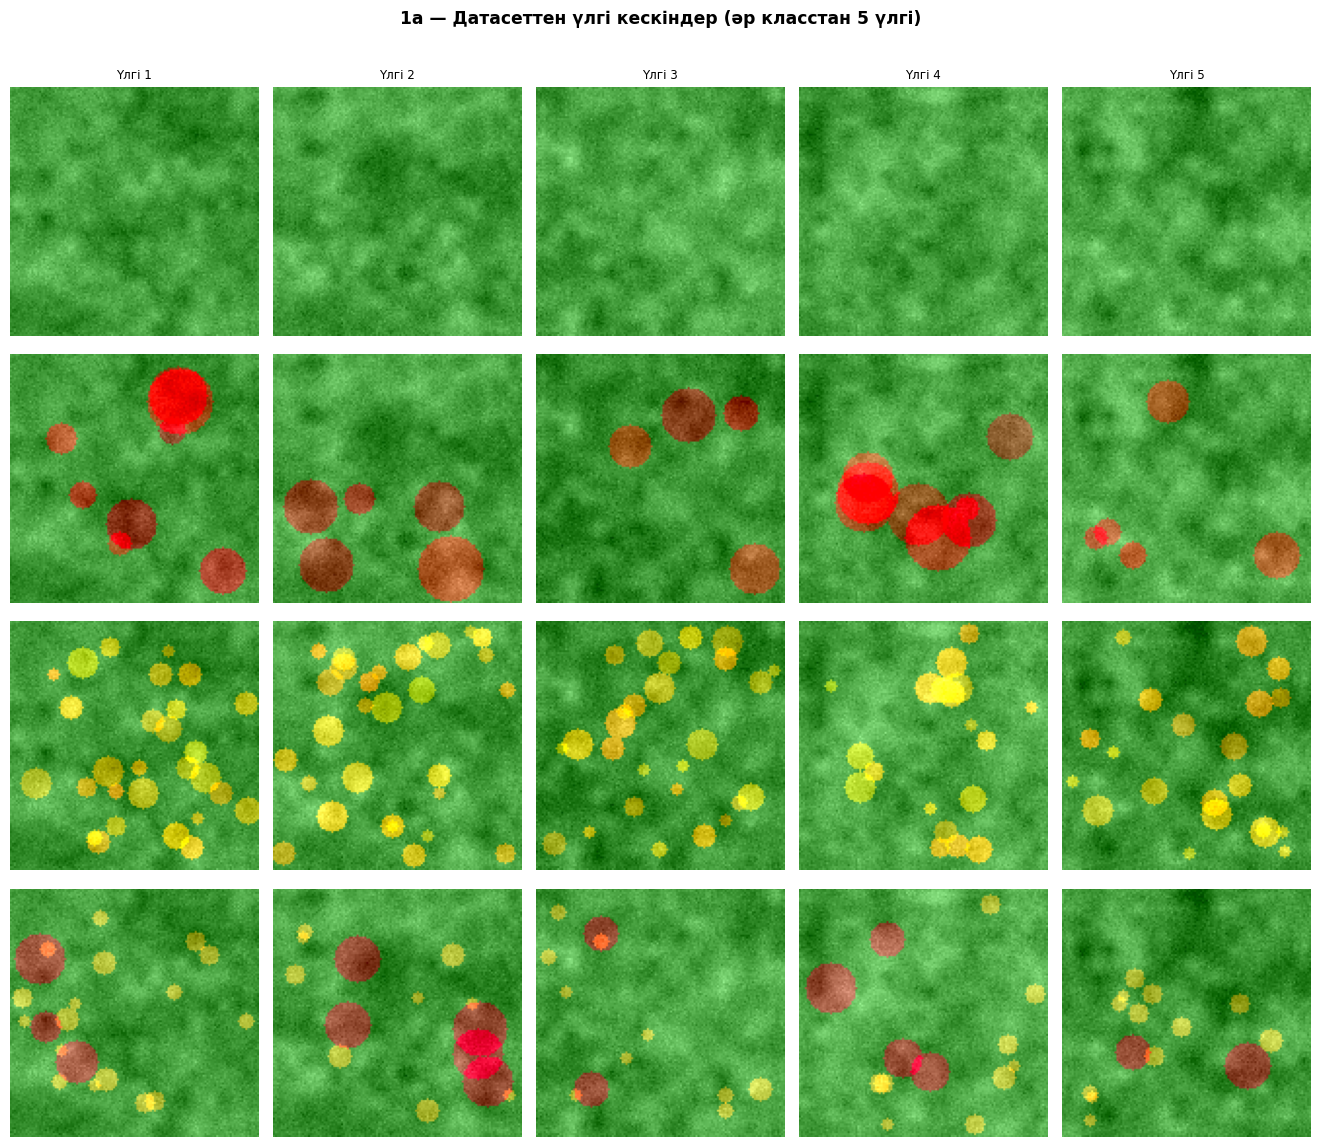

Кескіндерде визуальды айырмашылықтарды байқадыңыз ба?


In [ ]:
# ─── 1а. Әр класстан үлгі кескіндер ─────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('1а — Датасеттен үлгі кескіндер (әр класстан 5 үлгі)',
             fontsize=13, fontweight='bold', y=1.01)

for row, (cls_idx, cls_name, cls_kaz, cls_color) in enumerate(
        zip(range(4), CLASS_NAMES, CLASS_KAZ, CLASS_COLORS)):

    cls_images = images[labels == cls_idx]
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(cls_images[col])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'{cls_kaz}\n({cls_name})',
                          fontsize=10, fontweight='bold', color=cls_color,
                          rotation=0, labelpad=70, va='center')
        if row == 0:
            ax.set_title(f'Үлгі {col+1}', fontsize=9)

plt.tight_layout()
plt.show()
print('Кескіндерде визуальды айырмашылықтарды байқадыңыз ба?')

### 1б. Класс Таралуын Талдау ← **СӨЖ**

**Тапсырма:** Датасеттегі класс таралуын (distribution) талдап, бар-chart визуализация жаса.

**Орындау керек:**
1. `CLASS_NAMES` ішіндегі әр кластың кескін санын есепте (`np.sum(labels == i)` арқылы)
2. Барлық класс санын тізімге (`counts` атты) жина
3. `plt.bar()` арқылы бағаналы диаграмма сыз, әр бағанаға `CLASS_COLORS` түстерін бер
4. Диаграмманың тақырыбын, x/y осі белгілерін қаз. тілінде жаз
5. Жауап жаз: **«Датасет теңгерімді ме? Неге?»**

**Пайдалы функциялар:**
```python
counts = [np.sum(labels == i) for i in range(len(CLASS_NAMES))]
plt.bar(x_позициялар, биіктіктер, color=түстер_тізімі)
plt.xticks(позициялар, белгілер)
```

In [ ]:
# ─── 1б. Класс таралуы ──────────────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



**Жауабыңды жаз:**

> Датасет теңгерімді ме? Неге?
>
> _(Жауабыңды осында жаз)_

### 1в. Пиксель Статистикасы ← **СӨЖ**

**Тапсырма:** Әр класс үшін R, G, B каналдарының орташа мәнін есептеп, нәтижені кесте және диаграмма ретінде көрсет.

**Орындау керек:**
1. Цикл ішінде әр класс үшін сол класстың барлық кескіндерін ал: `class_imgs = images[labels == i]`
2. R, G, B каналдарының орташа мәнін есепте: `class_imgs[:, :, :, 0].mean()` (канал индексі 0, 1, 2)
3. Нәтижелерді `r_means`, `g_means`, `b_means` тізімдеріне жина
4. `plt.plot()` арқылы сызықтық диаграммада R (қызыл), G (жасыл), B (көк) мәндерін бейнеле
5. Жауап жаз: **«Қай канал класстарды ең жақсы ажырата алады?»**

**Пайдалы функциялар:**
```python
class_imgs = images[labels == cls_idx]  # Сол класстың кескіндері
mean_r = class_imgs[:, :, :, 0].mean() # R каналының орташа мәні
```

In [ ]:
# ─── 1в. Пиксель статистикасы ───────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



**Жауабыңды жаз:**

> Қай канал (R, G, немесе B) класстарды ең жақсы ажырата алады? Неге?
>
> _(Жауабыңды осында жаз)_

# Қадам 2: Кескінді Алдын Ала Өңдеу

ML моделіне кескіндерді тікелей беруге болады, бірақ алдын ала өңдеу нәтижені айтарлықтай жақсартады.

---
### 2а. Өлшемді Стандарттау
> **Оқытушы коды — өзгертпеңіз**

In [ ]:
# ─── 2а. Барлық кескіндер 128×128 өлшемінде екенін тексеру ──
print('=== Кескін өлшем статистикасы ===')
shapes = [img.shape for img in images]
unique_shapes = set(shapes)
print(f'Барлық кескін өлшемдері: {unique_shapes}')
print(f'Жалпы кескін саны: {len(images)}')
assert len(unique_shapes) == 1, 'Өлшемдер сәйкес емес!'
print('Барлық кескіндер бірдей өлшемде!')

# Бір кескіннің мән диапазонын тексеру
print(f'\nПиксель мәні диапазоны: [{images.min():.4f}, {images.max():.4f}]')
print(f'Орташа мән: {images.mean():.4f}')

=== Кескін өлшем статистикасы ===
Барлық кескін өлшемдері: {(128, 128, 3)}
Жалпы кескін саны: 240
Барлық кескіндер бірдей өлшемде!

Пиксель мәні диапазоны: [0.0000, 1.0000]
Орташа мән: 0.3674


### 2б. Түс Кеңістігіне Ауыстыру ← **СӨЖ**

**Контекст:** Аурудың түсін анықтауда **HSV кеңістігі** RGB-ге қарағанда тиімдірек. HSV-де:
- **H (Hue)** — реңк (0°–360°): жасыл ≈ 60°–150°, сарғыш-қызғылт ≈ 15°–45°
- **S (Saturation)** — қанықтық: ауру дақтары жоғары S-ке ие
- **V (Value)** — жарықтық

**Тапсырма:** Бір сау және бір ауру кескінді RGB → HSV-ге ауыстырып, H каналын салыстыр.

**Орындау керек:**
1. Датасеттен 1 сау (`labels == 0`) және 1 тат ауруы (`labels == 2`) кескінін ал
2. Екеуін де `color.rgb2hsv()` арқылы HSV форматына ауыстыр
3. 2×3 торда бейнеле: жоғарғы қатар — RGB, төменгі қатар — H, S, V каналдары
4. Жауап жаз: **«Сау және ауру жапырақтардың H каналындағы айырмашылығы қандай?»**

**Пайдалы функциялар:**
```python
img_hsv = color.rgb2hsv(img_rgb)  # RGB → HSV
H_channel = img_hsv[:, :, 0]     # Реңк каналы
S_channel = img_hsv[:, :, 1]     # Қанықтық каналы
V_channel = img_hsv[:, :, 2]     # Жарықтық каналы
```

In [ ]:
# ─── 2б. RGB → HSV конвертация ──────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



**Жауабыңды жаз:**

> Сау және тат ауруы жапырақтарының H (Hue) каналындағы негізгі айырмашылық қандай?
>
> _(Жауабыңды осында жаз)_

### 2в. Гаусс Шуын Азайту ← **СӨЖ**

**Контекст:** Нақты камерадан алынған кескіндерде шу болады. Шуды азайту жиек анықтауды жақсартады.

**Тапсырма:** Кескінге жасанды шу қосып, содан кейін Гаусс сүзгісімен жой.

**Орындау керек:**
1. `images[labels == 1][0]` арқылы қотыр ауруы кескінін ал
2. `filters.gaussian(img, sigma=1.5, channel_axis=-1)` арқылы сүзгіле (channel_axis=-1 — RGB үшін)
3. Бастапқы, сүзгіленген кескіндерді және олардың айырмасын (`np.abs(orig - filtered)`) қатар көрсет
4. Орташа абсолюттік айырманы (MAE) есептеп шығар

**Пайдалы функциялар:**
```python
from skimage import filters
img_filtered = filters.gaussian(img, sigma=1.5, channel_axis=-1)
difference   = np.abs(img_orig - img_filtered)
mae          = difference.mean()
```

In [ ]:
# ─── 2в. Гаусс сүзгісі ──────────────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



# Қадам 3: Аурудың Визуальды Белгілерін Табу

Ауруды анықтаудың негізгі идеясы — **дақтарды (lesions) сегментациялау**. Ауру дақтары жасыл емес түске ие болғандықтан, HSV маскасы арқылы бөліп алуға болады.

### 3а. HSV Маскасын Қолдану
> **Оқытушы коды — өзгертпеңіз**

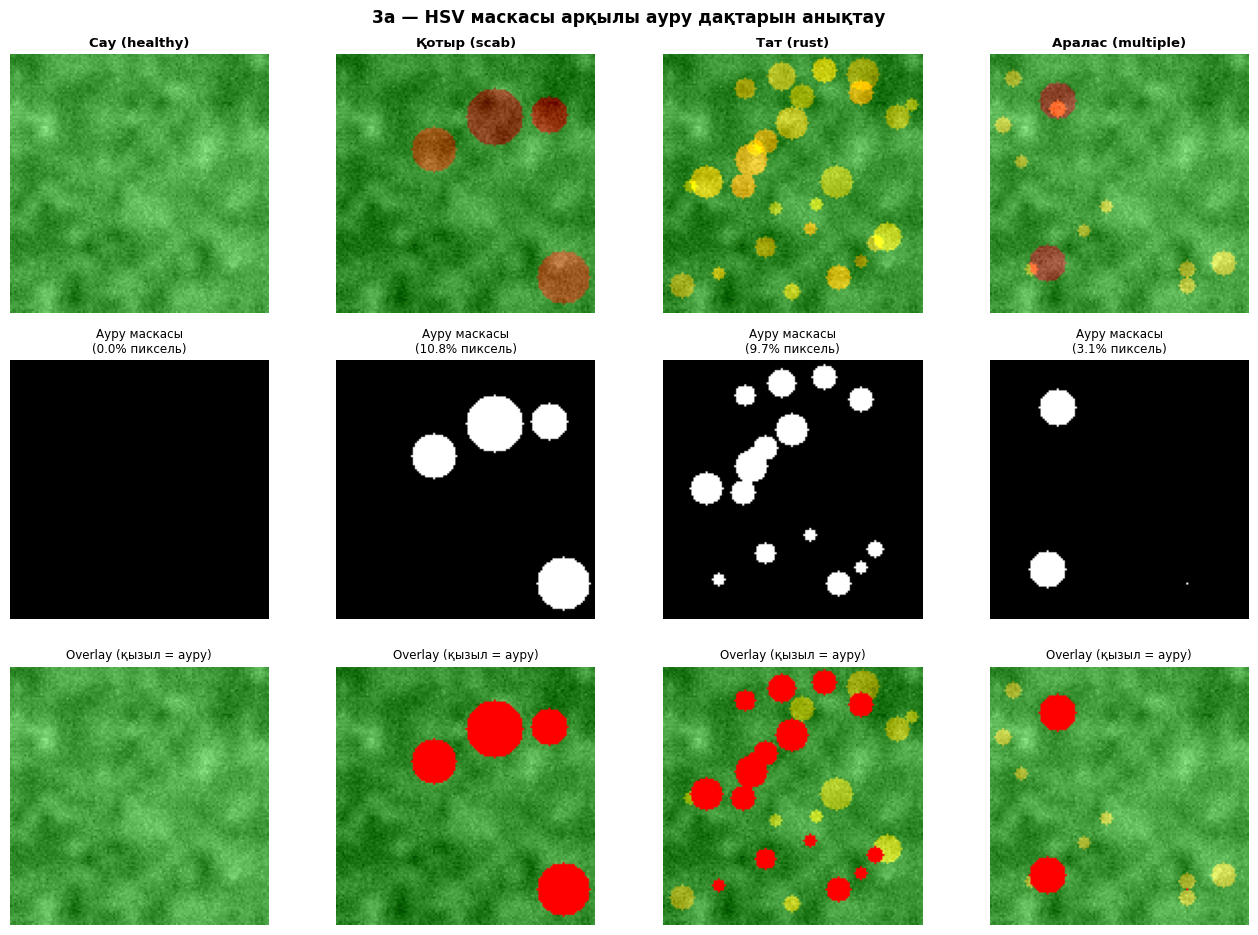

Сау жапырақта ауру маскасы өте аз (<5%), ауруларда жоғары болуы керек.


In [ ]:
# ─── 3а. Жасыл емес аймақтарды табу (HSV маскасы) ───────────

def create_disease_mask(img_rgb):
    """
    Жасыл емес (ауру) аймақтарды анықтайтын бинарлы маска жасайды.
    HSV кеңістігінде жасыл диапазонын анықтап, одан тыс аймақтарды ауру деп белгілейді.
    """
    img_hsv    = color.rgb2hsv(img_rgb)
    H, S, V    = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

    # Жасыл диапазон: H ∈ [0.18, 0.45], S > 0.15, V > 0.15
    green_mask = (H >= 0.18) & (H <= 0.45) & (S > 0.15) & (V > 0.15)

    # Жасыл ЕМЕС және жарқын аймақтар = ауру дақтары
    disease_mask = (~green_mask) & (S > 0.12) & (V > 0.15)
    return disease_mask

# Демонстрация: 4 класстан бір-бір кескін
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('3а — HSV маскасы арқылы ауру дақтарын анықтау',
             fontsize=13, fontweight='bold')

for col, (cls_idx, cls_name, cls_kaz) in enumerate(
        zip(range(4), CLASS_NAMES, CLASS_KAZ)):
    sample_img = images[labels == cls_idx][2]
    mask       = create_disease_mask(sample_img)
    ratio      = mask.sum() / mask.size * 100

    # Масканы кескін үстіне қызыл түспен салу
    overlay = sample_img.copy()
    overlay[mask, 0] = 1.0
    overlay[mask, 1] = 0.0
    overlay[mask, 2] = 0.0

    axes[0, col].imshow(sample_img)
    axes[0, col].set_title(f'{cls_kaz} ({cls_name})', fontsize=10, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(mask, cmap='gray')
    axes[1, col].set_title(f'Ауру маскасы\n({ratio:.1f}% пиксель)', fontsize=9)
    axes[1, col].axis('off')

    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Overlay (қызыл = ауру)', fontsize=9)
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()
print('Сау жапырақта ауру маскасы өте аз (<5%), ауруларда жоғары болуы керек.')

### 3б. Дақтарды Сегментациялау ← **СӨЖ**

**Контекст:** `create_disease_mask()` функциясы жалпы ауру аймақтарын анықтайды. Енді жеке дақтарды (spots/lesions) санап, олардың сипаттамаларын алу керек.

**Тапсырма:** Тат ауруы (`rust`) кескінінен жеке дақтарды табып, санап шығар.

**Орындау керек:**
1. `images[labels == 2][0]` арқылы тат кескінін ал
2. `create_disease_mask(img)` арқылы ауру маскасын жаса
3. `measure.label(mask)` арқылы дақтарды жеке аймақтарға бөл
4. `measure.regionprops(labeled)` арқылы аймақ сипаттамаларын ал
5. Ауданы (**area**) 10-нан үлкен аймақтарды ғана сүзіп шығар
6. Нәтижені кескін үстінде bounding box арқылы көрсет, дақ санын шығар

**Пайдалы функциялар:**
```python
from skimage import measure
labeled  = measure.label(mask)        # Аймақтарды белгілеу
regions  = measure.regionprops(labeled) # Сипаттамалар
# Сүзу: region.area > 10 шартымен
big_spots = [r for r in regions if r.area > 10]
# bounding box: r.bbox → (min_row, min_col, max_row, max_col)
```

In [ ]:
# ─── 3б. Дақтарды сегментациялау ───────────────────────────
import matplotlib.patches as mpatches

# КОДТЫ ОСЫНДА ЖАЗ



### 3в. Морфологиялық Тазалау ← **СӨЖ**

**Контекст:** Маскада шудан туындаған кішкентай жалған дақтар болуы мүмкін. Морфологиялық **opening** операциясы оларды жояды.

**Тапсырма:** Ауру маскасын морфологиялық тазалап, нәтижені салыстыр.

**Орындау керек:**
1. Қотыр (`scab`, `labels == 1`) кескінінен маска жаса
2. `morphology.binary_opening(mask, morphology.disk(2))` арқылы кішкентай шу нүктелерін жой
3. `morphology.binary_closing(cleaned, morphology.disk(3))` арқылы дақ ішіндегі саңылауларды жап
4. Бастапқы маска, opening, closing нәтижелерін қатар көрсет
5. Әр маскадағы `True` пиксель санын шығарып, пайызбен жаз

**Пайдалы функциялар:**
```python
from skimage import morphology
opened = morphology.binary_opening(mask, morphology.disk(2))  # Кішкентайды жою
closed = morphology.binary_closing(opened, morphology.disk(3)) # Саңылауды жабу
pixel_ratio = mask.sum() / mask.size * 100  # Пиксель пайызы
```

In [ ]:
# ─── 3в. Морфологиялық тазалау ──────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



# Қадам 4: Сипаттама Шығару (Feature Extraction)

ML моделі кескін пикселдерін тікелей қабылдай алады, бірақ **мағыналы сипаттамаларды шығару** нәтижені жақсартады. Бұл қадамда кескіннен сандық векторлар аламыз.

---
### 4а. Түс Гистограммасы
> **Оқытушы коды — өзгертпеңіз**

Түс гистограммасы өлшемі: (96,)
Мән диапазоны: [0.0000, 1.0000]


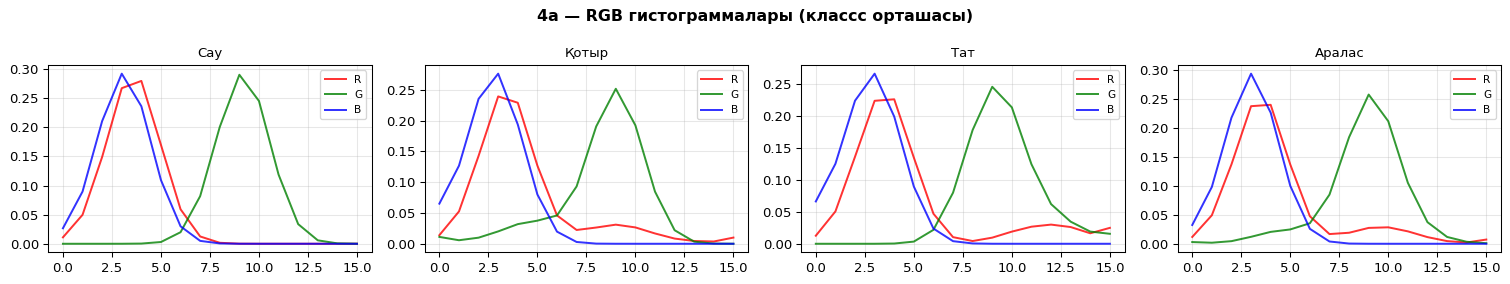

In [ ]:
# ─── 4а. Түс гистограммасы белгісі ──────────────────────────

def extract_color_histogram(img, bins=16):
    """
    RGB және HSV каналдарының гистограммасынан сипаттама векторын шығарады.
    Нәтиже: 16×3 (RGB) + 16×3 (HSV) = 96 өлшемді вектор
    """
    features = []
    # RGB гистограммасы
    for ch in range(3):
        hist, _ = np.histogram(img[:, :, ch], bins=bins, range=(0, 1))
        features.extend(hist / hist.sum())  # Нормализация

    # HSV гистограммасы
    img_hsv = color.rgb2hsv(img)
    for ch in range(3):
        hist, _ = np.histogram(img_hsv[:, :, ch], bins=bins, range=(0, 1))
        features.extend(hist / hist.sum())

    return np.array(features, dtype=np.float32)

# Тест: бір кескіннің сипаттама векторы
sample_feat = extract_color_histogram(images[0])
print(f'Түс гистограммасы өлшемі: {sample_feat.shape}')
print(f'Мән диапазоны: [{sample_feat.min():.4f}, {sample_feat.max():.4f}]')

# Класстар бойынша орташа гистограммаларды визуализациялау
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
fig.suptitle('4а — RGB гистограммалары (классс орташасы)', fontsize=12, fontweight='bold')

colors_rgb = ['red', 'green', 'blue']
for col, (cls_idx, cls_name, cls_kaz) in enumerate(
        zip(range(4), CLASS_NAMES, CLASS_KAZ)):
    cls_imgs = images[labels == cls_idx]
    ax = axes[col]
    for ch, ch_color in enumerate(colors_rgb):
        all_hist = []
        for img in cls_imgs:
            h, _ = np.histogram(img[:, :, ch], bins=16, range=(0, 1))
            all_hist.append(h / h.sum())
        mean_hist = np.mean(all_hist, axis=0)
        ax.plot(mean_hist, color=ch_color, alpha=0.8,
                label=['R', 'G', 'B'][ch])
    ax.set_title(f'{cls_kaz}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4б. Текстура Сипаттамалары (LBP) ← **СӨЖ**

**Контекст:** **Local Binary Pattern (LBP)** — текстураны кодтайтын алгоритм. Әр пиксель үшін оның 8 көршісімен салыстырылып, бинарлы сан шығарылады. Тегіс және дақтарлы текстуралар әртүрлі LBP гистограммасын береді.

```
Сосед пикселдер:
  5 3 7          5>4=1  3>4=0  7>4=1
  2 4 8  →  →   2>4=0   (орт.) 8>4=1   →  10010111₂ = 151
  1 6 9          1>4=0  6>4=1  9>4=1
```

**Тапсырма:** Барлық кескіндер үшін LBP гистограммасын есептеп, сипаттама ретінде пайдалан.

**Орындау керек:**
1. `extract_lbp_features(img)` функциясын жаз:
   - Кескінді сұр реңкті форматқа ауыстыр: `color.rgb2gray(img)`
   - `local_binary_pattern(gray, P=8, R=1, method='uniform')` арқылы LBP есепте
   - `np.histogram(lbp, bins=10, range=(0, 10))` арқылы гистограмма жаса
   - Гистограмманы нормализацияла (`/ hist.sum()`) және қайтар
2. Функцияны `images[0]` кескіні үшін тексер, нәтиже өлшемін шығар
3. Сау және қотыр кескіндерінің LBP гистограммаларын бір диаграммада салыстыр

**Пайдалы функциялар:**
```python
from skimage.feature import local_binary_pattern
gray = color.rgb2gray(img)                          # Сұр реңкті
lbp  = local_binary_pattern(gray, P=8, R=1, method='uniform')
hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
```

In [ ]:
# ─── 4б. LBP текстура сипаттамасы ───────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



### 4в. Форма Сипаттамалары ← **СӨЖ**

**Контекст:** Ауру дақтарының **формасы** да маңызды белгі. Тат ауруы — ұсақ дөңгелек дақтар, қотыр ауруы — ірі дұрыс емес пішінді дақтар.

**Тапсырма:** Ауру маскасынан форма сипаттамаларын шығаратын функция жаз.

**Орындау керек:**
1. `extract_shape_features(img)` функциясын жаз:
   - `create_disease_mask(img)` арқылы маска жаса
   - Маскадағы `True` пикселдердің пайызын есепте → `disease_ratio`
   - `measure.label(mask)` → `measure.regionprops()` арқылы дақтар сипаттамасын ал
   - Ауданы (area) 5-тен үлкен дақтардың санын (`n_spots`), орташа ауданын (`mean_area`), орташа эксцентриситетін (`mean_eccentricity`) есепте
   - `[disease_ratio, n_spots, mean_area, mean_eccentricity]` — 4 өлшемді вектор қайтар
2. Функцияны 4 класстан бір-бір кескін үшін шақырып, нәтижелерді кесте ретінде шығар

**Пайдалы функциялар:**
```python
disease_ratio = mask.sum() / mask.size          # Ауру пиксель үлесі
labeled       = measure.label(mask)              # Аймақтарды белгілеу
regions       = measure.regionprops(labeled)     # Сипаттамалар
big_regions   = [r for r in regions if r.area > 5]
n_spots       = len(big_regions)                 # Дақ саны
mean_area     = np.mean([r.area for r in big_regions]) if big_regions else 0
# r.eccentricity: 0=дөңгелек, 1=сызыққа жақын
```

In [ ]:
# ─── 4в. Форма сипаттамалары ────────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



# Қадам 5: ML Классификация

Енді барлық сипаттамаларды біріктіріп, **Random Forest** классификаторын оқытамыз.

### 5а. Сипаттама Матрицасын Жасау
> **Оқытушы коды — өзгертпеңіз**

In [ ]:
# ─── 5а. Барлық сипаттамаларды біріктіру ────────────────────
print('⏳ Сипаттама матрицасы жасалуда (бұл 1–2 минут алуы мүмкін)...')

def extract_all_features(img):
    """
    Бір кескіннен барлық сипаттамаларды шығарады:
    - Түс гистограммасы: 96 өлшем
    - Жапырақ статистикасы: 6 өлшем
    Барлығы: 102 өлшемді вектор
    """
    feats = []

    # 1. Түс гистограммасы (96 өлшем)
    feats.extend(extract_color_histogram(img, bins=16))

    # 2. Қарапайым статистика (6 өлшем)
    img_hsv = color.rgb2hsv(img)
    for ch in range(3):
        feats.append(img[:, :, ch].mean())
        feats.append(img[:, :, ch].std())

    return np.array(feats, dtype=np.float32)

# Барлық кескіндер үшін сипаттамалар
X = np.array([extract_all_features(img) for img in images])
y = labels.copy()

print(f'\nСипаттама матрицасы дайын!')
print(f'   X өлшемі : {X.shape}  ({X.shape[0]} кескін × {X.shape[1]} сипаттама)')
print(f'   y өлшемі : {y.shape}')
print(f'   NaN бар ма: {np.isnan(X).any()}')
print(f'   Inf бар ма: {np.isinf(X).any()}')

⏳ Сипаттама матрицасы жасалуда (бұл 1–2 минут алуы мүмкін)...

Сипаттама матрицасы дайын!
   X өлшемі : (240, 102)  (240 кескін × 102 сипаттама)
   y өлшемі : (240,)
   NaN бар ма: False
   Inf бар ма: False


### 5б. Модельді Оқыту ← **СӨЖ**

**Контекст:** **Random Forest** — бірнеше шешім ағашынан тұратын ансамбль моделі. Ол CV тапсырмаларында жақсы жұмыс істейді, гиперпараметрлерге аз сезімтал.

**Тапсырма:** Деректерді бөліп, Random Forest моделін оқыт.

**Орындау керек:**
1. `StandardScaler()` арқылы `X`-ті нормализацияла (`fit_transform` тек train-ға, `transform` test-ке)
2. `train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)` арқылы бөл
3. `RandomForestClassifier(n_estimators=100, random_state=42)` моделін жаса
4. `model.fit(X_train, y_train)` арқылы оқыт
5. Train және test дәлдіктерін (`model.score()`) шығар

**Пайдалы функциялар:**
```python
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)     # Масштабтау

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)
```

In [ ]:
# ─── 5б. Random Forest моделін оқыту ───────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



### 5в. Нәтижелерді Бағалау ← **СӨЖ**

**Тапсырма:** Модель нәтижесін толық бағала: confusion matrix, classification report және сипаттамалардың маңызын (feature importance) шығар.

**Орындау керек:**
1. `y_pred = model.predict(X_test)` арқылы болжам жаса
2. `classification_report(y_test, y_pred, target_names=CLASS_KAZ)` шығар
3. Confusion matrix-ті `ConfusionMatrixDisplay` арқылы визуализацияла
4. `model.feature_importances_` арқылы ең маңызды 10 сипаттаманы бар-chart ретінде бейнеле
5. Жауап жаз: **«Модель қай класты ең нашар таниды? Неге?»**

**Пайдалы функциялар:**
```python
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=CLASS_KAZ))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_KAZ)
disp.plot()

importances = model.feature_importances_   # Сипаттама маңыздылығы
top10_idx   = np.argsort(importances)[-10:] # Ең жоғары 10-ы
```

In [ ]:
# ─── 5в. Нәтижелерді бағалау ────────────────────────────────

# КОДТЫ ОСЫНДА ЖАЗ



**Жауабыңды жаз:**

> Модель қай класты ең нашар таниды? Confusion matrix-ке сүйене отырып, неге солай болуы мүмкін екенін түсіндір.
>
> _(Жауабыңды осында жаз)_

# Қадам 6: Жалпы Талдау және Қорытынды ← **СӨЖ**

Бұл соңғы қадамда жобаның барлық нәтижелерін қорытындылап, өмірдегі қолданысын талқылайсыз.

**Тапсырма:** Жоба бойынша толық есеп дайында.

**Орындау керек:**
1. Модельдің **дұрыс болжаған** 2 кескінін және **қате болжаған** 2 кескінін датасеттен тауып, бейнеле. Әр кескіннің үстіне нақты класс пен болжам класын жаз.
2. Мына 3 сұраққа жазбаша жауап бер (әрқайсысына ≥ 3 сөйлем):
   - **А)** Осы жүйені нақты ауыл шаруашылығында қолдану үшін қандай қосымша жұмыстар керек?
   - **Б)** Модельдің дәлдігін жақсарту үшін қандай 2 жақсарту жолын ұсынасыз?
   - **В)** CNN (терең оқыту) мен Random Forest арасындағы айырмашылық пен осы тапсырмаға қайсысы қолайлырақ, неге?

**Пайдалы функциялар:**
```python
# Дұрыс/қате болжамдарды табу
y_pred_all = model.predict(X_scaled)         # Барлығын болжа
correct_idx = np.where(y_pred_all == y)[0]   # Дұрыс индекстер
wrong_idx   = np.where(y_pred_all != y)[0]   # Қате индекстер
```

In [ ]:
# ─── 6. Дұрыс және қате болжамдарды визуализациялау ─────────

# КОДТЫ ОСЫНДА ЖАЗ



## Жазбаша Жауаптар

### А) Нақты қолдану үшін қандай қосымша жұмыстар керек?

> _(Жауабыңды осында жаз — ≥ 3 сөйлем)_


### Б) Модельдің дәлдігін жақсарту үшін 2 жол:

> **1-жол:** _(жаз)_
>
> **2-жол:** _(жаз)_


### В) CNN vs Random Forest — осы тапсырмаға қайсысы қолайлы?

> _(Жауабыңды осында жаз — ≥ 3 сөйлем)_

# Тексеру Парағы

| # | Тапсырма | Орындалды? | Балл |
|:-:|----------|:----------:|:----:|
| 1б | Класс таралуы — bar-chart | ☐ | /10 |
| 1в | Пиксель статистикасы — R/G/B графигі | ☐ | /10 |
| 2б | RGB → HSV конвертация + жауап | ☐ | /10 |
| 2в | Гаусс сүзгісі + MAE | ☐ | /10 |
| 3б | Дақтарды сегментациялау + bounding box | ☐ | /10 |
| 3в | Морфологиялық тазалау + салыстыру | ☐ | /10 |
| 4б | LBP текстура функциясы + график | ☐ | /10 |
| 4в | Форма сипаттамалары + кесте | ☐ | /10 |
| 5б | Random Forest оқыту + дәлдік | ☐ | /10 |
| 5в | Confusion matrix + feature importance + жауап | ☐ | /15 |
| 6 | Дұрыс/қате визуализация + 3 сұрақ жауабы | ☐ | /15 |
| | **БАРЛЫҒЫ** | | **/120** |


>  **Тапсыру форматы:** `.ipynb` файлын барлық шығыс нәтижелерімен (output) бірге тапсырыңыз.